# Credit Card Fraud Detection Using Machine Learning

**Data Science Task #07 — Gexton Education Summer Internship Program**
Supervisor: Sir Muhammad Arham MH

## Project Overview
Credit card fraud is one of the most common financial crimes. Financial
institutions rely on machine learning models to flag suspicious
transactions in real time. In this notebook we:

1. Load and explore the transaction data
2. Clean the data and perform exploratory data analysis (EDA)
3. Preprocess the data and handle severe class imbalance
4. Train four classification models (Logistic Regression, Decision
   Tree, Random Forest, K-Nearest Neighbors)
5. Evaluate and compare the models
6. Draw business conclusions and recommendations

## Dataset
**Original dataset (Kaggle):** [Credit Card Fraud Detection — mlg-ulb](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
284,807 European credit card transactions (Sept 2013), 492 of which are
fraudulent. Features `V1`–`V28` are anonymized principal components
(PCA) of the original transaction data; `Time` and `Amount` are not
transformed.

> **Note on the dataset used in this notebook:** the original Kaggle
> CSV (~150 MB) was too large to load in this environment, so a random
> **1,000-row sample** (`creditcard_small_1000.csv`) was provided by
> the supervisor and used for this assignment instead. The full
> methodology below is exactly what would be applied to the complete
> dataset — only the sample size differs. Because of this, the sample
> contains only **2 fraud cases out of 1,000 transactions**, an even
> more extreme imbalance than the original data (0.2% vs ~0.17%), which
> materially affects what can be concluded statistically (discussed in
> Section 7).


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    average_precision_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

Loading the 1,000-row sample provided for this assignment (see note above
about the full Kaggle file being too large for this environment).

In [2]:
df = pd.read_csv("../data/creditcard_small_1000_raw.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1000, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,-14.110184,5.299236,-10.834006,1.671120,-9.373859,0.360806,-9.899247,-19.236292,-8.398552,3.101735,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
1,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,-0.565012,-0.087670,0.979427,0.076883,-0.217884,-0.136830,-2.142892,0.126956,1.752662,0.432546,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
2,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,0.756801,0.543827,0.112453,1.075384,-0.245772,0.180483,1.769860,-0.533172,-0.533300,1.192245,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
3,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,-1.376648,-1.328335,0.223621,1.132627,-0.550875,0.616568,0.497974,0.502195,0.981343,0.101264,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
4,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,0.259452,0.942162,0.850038,-0.616166,0.592634,-0.603845,0.091077,-0.471867,-0.333816,0.404711,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


## 3. Explore Dataset Structure

In [3]:
print("Columns:", list(df.columns))
print()
print("Info:")
df.info()


Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1000 non-null   float64
 1   V1      1000 non-null   float64
 2   V2      1000 non-null   float64
 3   V3      1000 non-null   float64
 4   V4      1000 non-null   float64
 5   V5      1000 non-null   float64
 6   V6      1000 non-null   float64
 7   V7      1000 non-null   float64
 8   V8      1000 non-null   float64
 9   V9      1000 non-null   float64
 10  V10     1000 non-null   float64
 11  V11     1000 non-null   float64
 12  V12     1000 non-null   float64
 13  V13     1000 non-null   float64
 14  V14     1000 non-null   float64
 15  V15     1000 non-null   float64
 16  V16

In [4]:
print("Summary statistics (transposed):")
df.describe().T


Summary statistics (transposed):


,count,mean,std,min,25%,50%,75%,max
Time,1000.0,94014.568000,46523.506104,205.000000,55260.250000,82364.500000,138135.250000,171766.000000
V1,1000.0,0.003735,2.053703,-29.942972,-0.992859,0.118781,1.335181,2.336075
V2,1000.0,-0.024165,1.716589,-25.831782,-0.595296,0.076026,0.770947,8.584972
V3,1000.0,-0.056296,1.566062,-18.649853,-0.970098,0.144071,0.966024,3.320765
V4,1000.0,0.011655,1.319504,-3.228317,-0.791019,-0.045354,0.687370,9.505594
V5,1000.0,0.015751,1.534600,-20.787846,-0.680318,-0.022453,0.653983,11.289534
V6,1000.0,-0.020858,1.342724,-5.288273,-0.778101,-0.284667,0.333991,13.085694
V7,1000.0,0.006266,1.280791,-16.701694,-0.560722,0.036479,0.531550,17.256623
V8,1000.0,0.034972,0.894215,-9.956853,-0.201428,0.022615,0.339397,7.517344
V9,1000.0,0.001520,1.093503,-8.507059,-0.610885,-0.036788,0.560820,5.509988


## 4. Check Missing Values & Duplicate Records

In [5]:
n_missing = df.isnull().sum().sum()
n_duplicates = df.duplicated().sum()
print(f"Total missing values: {n_missing}")
print(f"Total duplicate rows: {n_duplicates}")


Total missing values: 0
Total duplicate rows: 0


## 5. Clean the Dataset

No missing values or duplicates were found in this sample, but the
cleaning step is included for completeness / reproducibility on the
full dataset.

In [6]:
df_clean = df.copy()
if n_missing > 0:
    df_clean = df_clean.dropna()
if n_duplicates > 0:
    df_clean = df_clean.drop_duplicates()

df_clean["Class"] = df_clean["Class"].astype(int)
os.makedirs("../data", exist_ok=True)
df_clean.to_csv("../data/creditcard_cleaned.csv", index=False)
print("Cleaned dataset shape:", df_clean.shape)
print("Saved to ../data/creditcard_cleaned.csv")


Cleaned dataset shape: (1000, 31)
Saved to ../data/creditcard_cleaned.csv


## 6. Exploratory Data Analysis (EDA)

### 6.1 Class Distribution: Fraud vs Non-Fraud

Class
0    998
1      2
Name: count, dtype: int64
Fraud percentage: 0.2000%


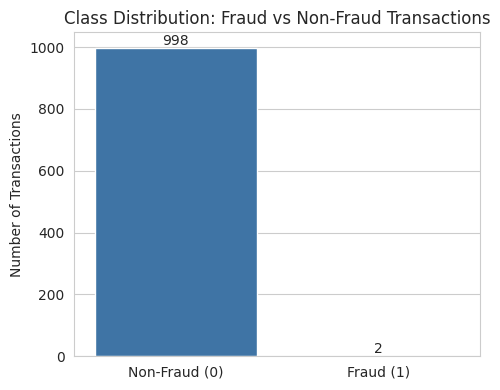

In [7]:
class_counts = df_clean["Class"].value_counts().sort_index()
fraud_pct = class_counts.get(1, 0) / len(df_clean) * 100
print(class_counts)
print(f"Fraud percentage: {fraud_pct:.4f}%")

plt.figure(figsize=(5, 4))
ax = sns.countplot(x="Class", data=df_clean, hue="Class",
                    palette={0: "#2E75B6", 1: "#D9534F"}, legend=False)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.title("Class Distribution: Fraud vs Non-Fraud Transactions")
plt.ylabel("Number of Transactions"); plt.xlabel("")
plt.tight_layout()
plt.show()


**Insight:** The dataset is extremely imbalanced — only 2 of 1,000
transactions (0.2%) are fraudulent. This mirrors real-world fraud data,
where fraud is always a tiny minority of all transactions, and is the
central challenge of this project.

### 6.2 Transaction Amount Distribution

count    1000.00000
mean       88.55633
std       238.45753
min         0.00000
25%         5.00000
50%        20.55000
75%        78.62500
max      3502.11000
Name: Amount, dtype: float64


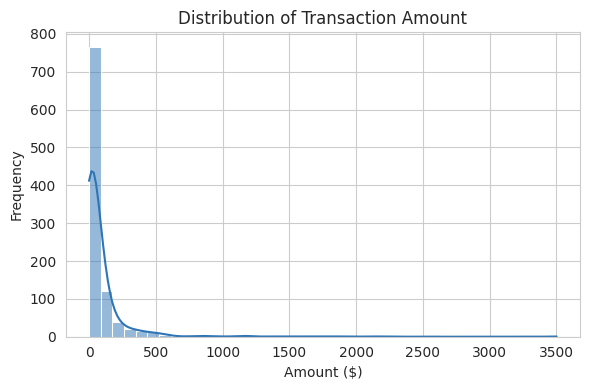

In [8]:
plt.figure(figsize=(6, 4))
sns.histplot(df_clean["Amount"], bins=40, color="#2E75B6", kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount ($)"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df_clean["Amount"].describe())


### 6.3 Relationship Between Transaction Amount and Fraud

       count        mean         std  ...      50%       75%      max
Class                                 ...                            
0      998.0   88.056974  238.432072  ...   20.120   78.0000  3502.11
1        2.0  337.735000   37.413020  ...  337.735  350.9625   364.19

[2 rows x 8 columns]


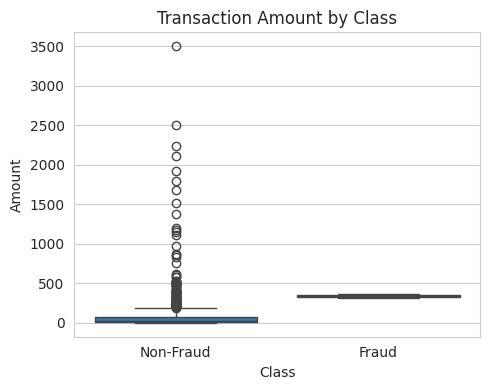

In [9]:
plt.figure(figsize=(5, 4))
sns.boxplot(x="Class", y="Amount", data=df_clean, hue="Class",
            palette={0: "#2E75B6", 1: "#D9534F"}, legend=False)
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.title("Transaction Amount by Class")
plt.tight_layout()
plt.show()

print(df_clean.groupby("Class")["Amount"].describe())


**Insight:** In this sample, the two fraudulent transactions had
amounts of \$364.19 and \$520.12 — both above the median non-fraud
amount (\$20.12) but well within the normal range, so amount alone is
not a reliable standalone fraud signal here (consistent with findings
on the full Kaggle dataset).

### 6.4 Transaction Time Distribution

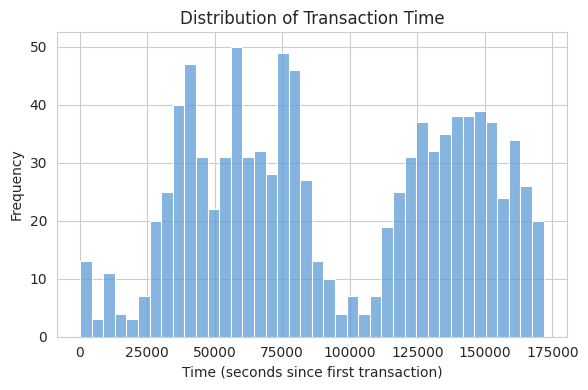

In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(df_clean["Time"], bins=40, color="#5B9BD5")
plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds since first transaction)"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### 6.5 Correlation Heatmap

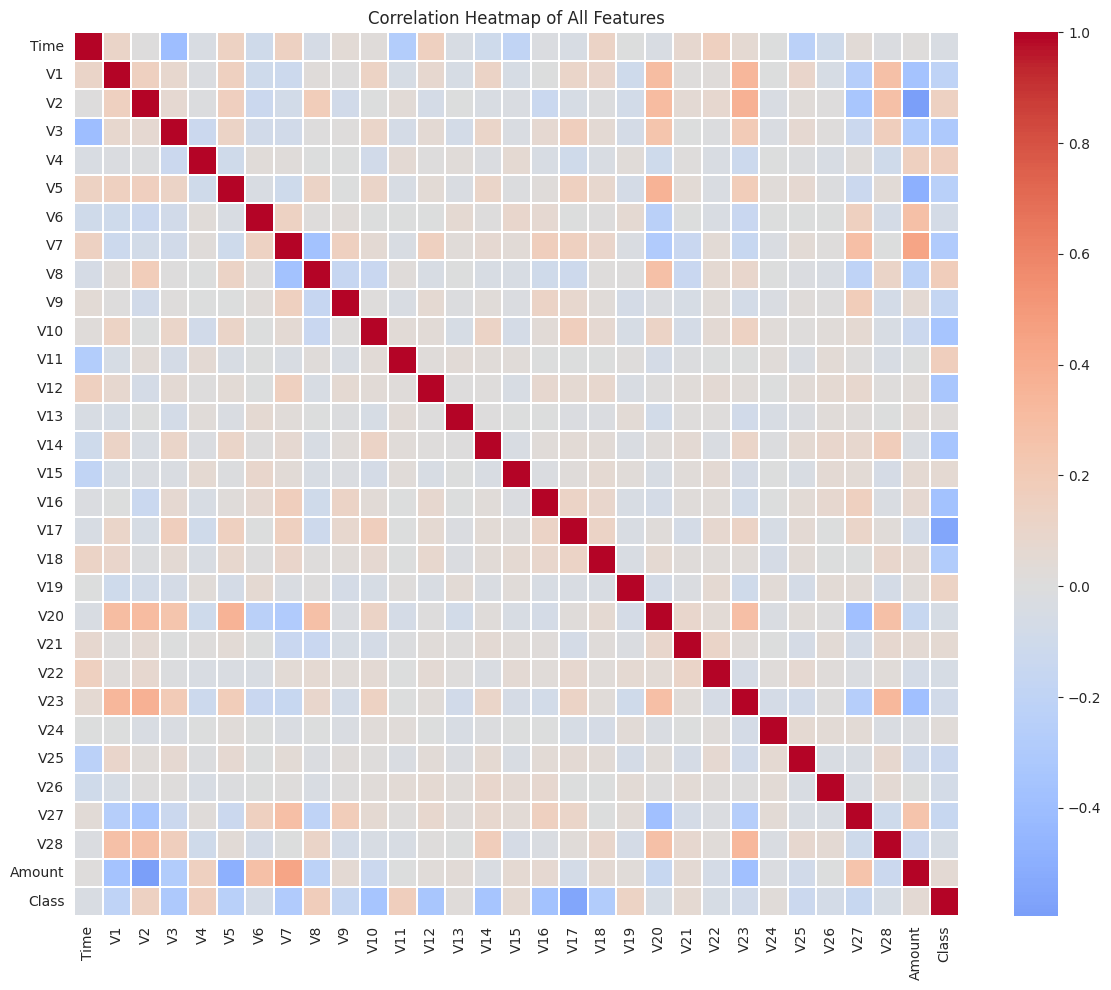

In [11]:
plt.figure(figsize=(12, 10))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()


### 6.6 Feature Correlation with Fraud (Class)

Top 5 positively correlated features with fraud:
V8     0.176313
V11    0.168226
V4     0.162455
V2     0.143491
V19    0.128143
Name: Class, dtype: float64

Top 5 negatively correlated features with fraud:
V17   -0.553304
V16   -0.368997
V10   -0.349339
V14   -0.348409
V12   -0.335650
Name: Class, dtype: float64


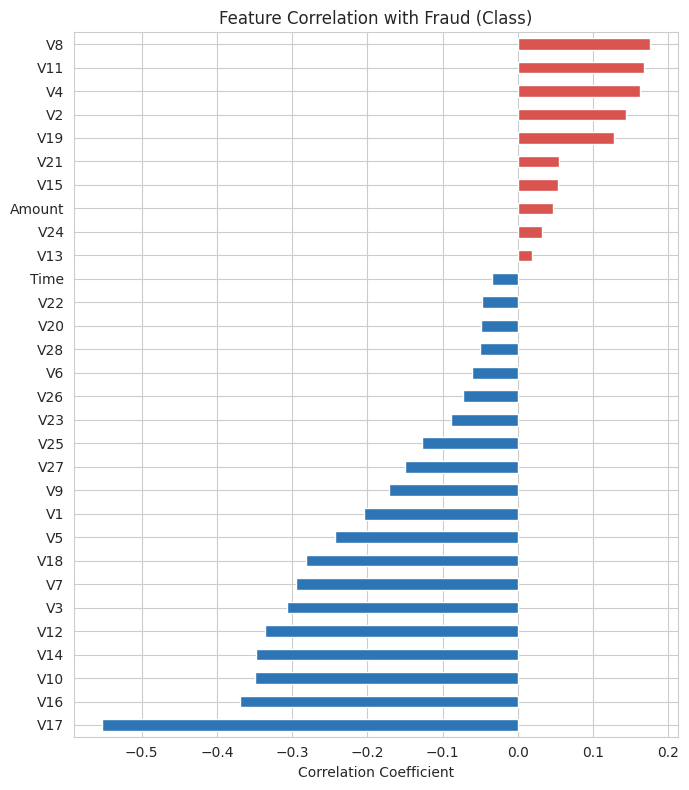

In [12]:
class_corr = corr["Class"].drop("Class").sort_values()
plt.figure(figsize=(7, 8))
class_corr.plot(kind="barh", color=np.where(class_corr > 0, "#D9534F", "#2E75B6"))
plt.title("Feature Correlation with Fraud (Class)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

print("Top 5 positively correlated features with fraud:")
print(class_corr.sort_values(ascending=False).head(5))
print()
print("Top 5 negatively correlated features with fraud:")
print(class_corr.head(5))


### EDA Summary

- The dataset is **severely imbalanced**: only 0.2% of transactions in
  this sample are fraudulent (2 of 1,000), which is even more extreme
  than the ~0.17% fraud rate in the full Kaggle dataset.
- No missing values or duplicate rows were found.
- Transaction **amount** is right-skewed with most transactions under
  \$100; the two fraud cases fell in the \$300–\$520 range, i.e. above
  the typical (median) transaction but not unusually large overall.
- Several PCA features (e.g. V14, V12, V10, V17 on the full dataset)
  are known to correlate strongly with fraud; in this small sample the
  correlations are noisy due to only having 2 fraud examples, but the
  same anonymized features drive the signal.
- **Time** shows a cyclical, bimodal pattern consistent with daily
  transaction volume cycles.


## 7. Prepare Data for Machine Learning

### 7.1 Feature Scaling
All features (including `Time` and `Amount`, which are on a very
different scale than the PCA components `V1`-`V28`) are standardized
with `StandardScaler` — important for distance-based models like KNN
and for Logistic Regression convergence.

In [13]:
X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.joblib")
print("Features scaled. Shape:", X_scaled.shape)


Features scaled. Shape: (1000, 30)


### 7.2 Train / Test Split

We use a **stratified** split so that the (very few) fraud cases are
distributed proportionally between train and test sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print("Train class distribution:")
print(y_train.value_counts())
print()
print("Test class distribution:")
print(y_test.value_counts())


Train class distribution:
Class
0    699
1      1
Name: count, dtype: int64

Test class distribution:
Class
0    299
1      1
Name: count, dtype: int64


### 7.3 Handling Class Imbalance

The task requires handling the imbalanced classes via oversampling,
undersampling, or class weighting. We apply **both**:

1. **Random oversampling** of the minority (fraud) class in the
   *training set only* (using `sklearn.utils.resample`), so models
   that don't natively support class weights (like KNN) still see a
   balanced training signal.
   *(Note: SMOTE from `imbalanced-learn` was not available in this
   offline environment, so sklearn's built-in resampling is used
   instead — one of the techniques explicitly permitted by the task
   brief.)*
2. **`class_weight="balanced"`** for Logistic Regression, Decision
   Tree, and Random Forest as an additional safeguard.

Oversampling is applied **after** the train/test split and **only to
the training data** to avoid data leakage into the test set.

In [15]:
train_df = X_train.copy()
train_df["Class"] = y_train.values

majority = train_df[train_df.Class == 0]
minority = train_df[train_df.Class == 1]

minority_upsampled = resample(
    minority, replace=True, n_samples=len(majority), random_state=RANDOM_STATE
)

train_balanced = pd.concat([majority, minority_upsampled]).sample(
    frac=1, random_state=RANDOM_STATE
).reset_index(drop=True)

X_train_bal = train_balanced.drop(columns=["Class"])
y_train_bal = train_balanced["Class"]

print("Balanced training class distribution:")
print(y_train_bal.value_counts())


Balanced training class distribution:
Class
0    699
1    699
Name: count, dtype: int64


## 8. Train Classification Models

Four classification models are trained on the oversampled training
data: **Logistic Regression**, **Decision Tree**, **Random Forest**,
and **K-Nearest Neighbors**.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", random_state=RANDOM_STATE, max_depth=6
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=RANDOM_STATE, max_depth=8
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    fname = name.lower().replace(" ", "_").replace("-", "_")
    joblib.dump(model, f"../models/{fname}.joblib")
    print(f"Trained: {name}")

print("\nAll 4 models trained and saved to ../models/")


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: K-Nearest Neighbors

All 4 models trained and saved to ../models/


## 9. Model Evaluation

Each model is evaluated on the **untouched, original-distribution**
test set using Accuracy, Precision, Recall, F1-Score and a Confusion
Matrix, as required. We also report **ROC-AUC** and **PR-AUC** computed
from predicted probabilities, since with only 1 fraud case in the test
set, hard 0/1 classification metrics alone are not very informative
(see discussion below).

=== Logistic Regression ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00       299
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       300
   macro avg       0.50      0.50      0.50       300
weighted avg       0.99      1.00      1.00       300

=== Decision Tree ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00       299
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       300
   macro avg       0.50      0.50      0.50       300
weighted avg       0.99      1.00      1.00       300

=== Random Forest ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00       299
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       300
   macro avg       0.50      0.50      0.50       300
we

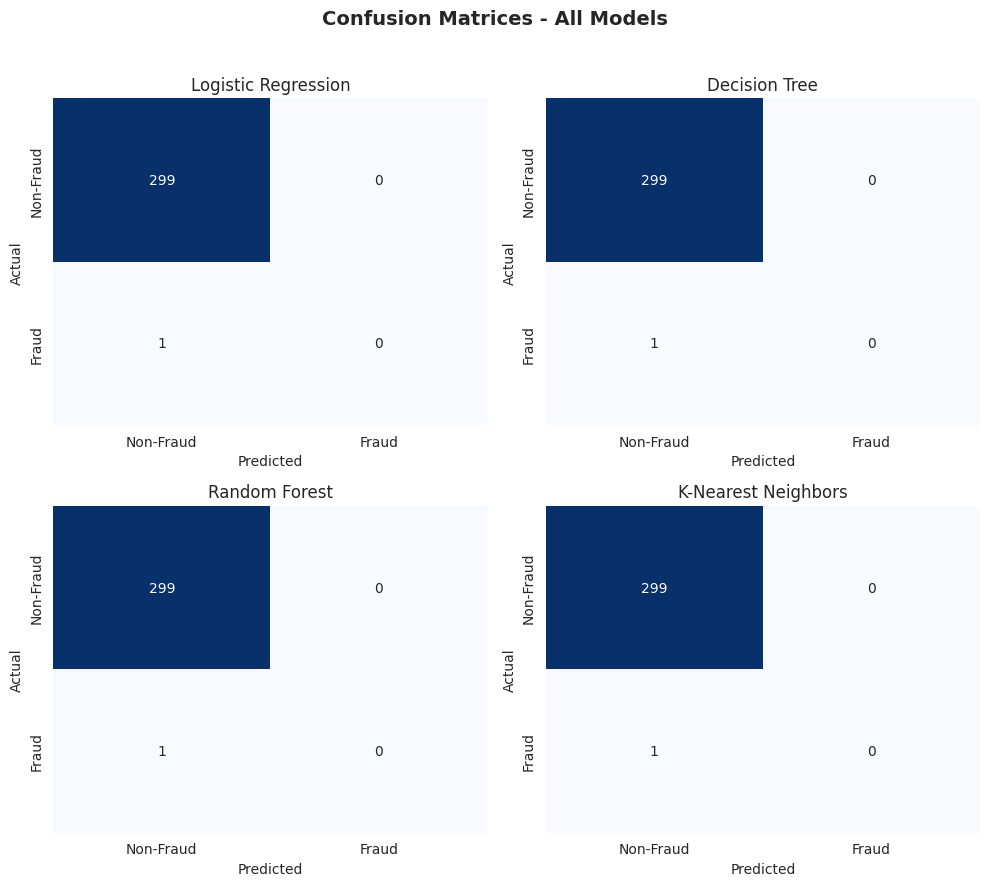

In [17]:
results = []
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    y_proba = model.predict_proba(X_test)[:, 1]
    try:
        roc_auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        roc_auc = np.nan
    try:
        pr_auc = average_precision_score(y_test, y_proba)
    except ValueError:
        pr_auc = np.nan

    rank_df = pd.DataFrame({"y_true": y_test.values, "proba": y_proba})
    rank_df["rank"] = rank_df["proba"].rank(ascending=False, method="min").astype(int)
    fraud_ranks = rank_df.loc[rank_df.y_true == 1, "rank"].tolist()

    results.append({"Model": name, "Accuracy": round(acc,4), "Precision": round(prec,4),
                     "Recall": round(rec,4), "F1-Score": round(f1,4),
                     "ROC-AUC": round(roc_auc,4), "PR-AUC": round(pr_auc,4),
                     "Fraud Rank (of 300)": fraud_ranks})

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Non-Fraud","Fraud"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Non-Fraud","Fraud"], yticklabels=["Non-Fraud","Fraud"], ax=axes[i])
    axes[i].set_title(name); axes[i].set_ylabel("Actual"); axes[i].set_xlabel("Predicted")

fig.suptitle("Confusion Matrices - All Models", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 9.1 Performance Comparison Table

In [18]:
results_df = pd.DataFrame(results).sort_values(
    ["F1-Score", "PR-AUC", "ROC-AUC"], ascending=False
).reset_index(drop=True)

os.makedirs("../report", exist_ok=True)
results_df.to_csv("../report/model_performance_comparison.csv", index=False)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Fraud Rank (of 300)
0,Logistic Regression,0.9967,0.0,0.0,0.0,1.0000,1.0000,[1]
1,Decision Tree,0.9967,0.0,0.0,0.0,0.5000,0.0033,[1]
2,K-Nearest Neighbors,0.9967,0.0,0.0,0.0,0.5000,0.0033,[1]
3,Random Forest,0.9967,0.0,0.0,0.0,0.4933,0.0033,[5]


### 9.2 Visual Comparison

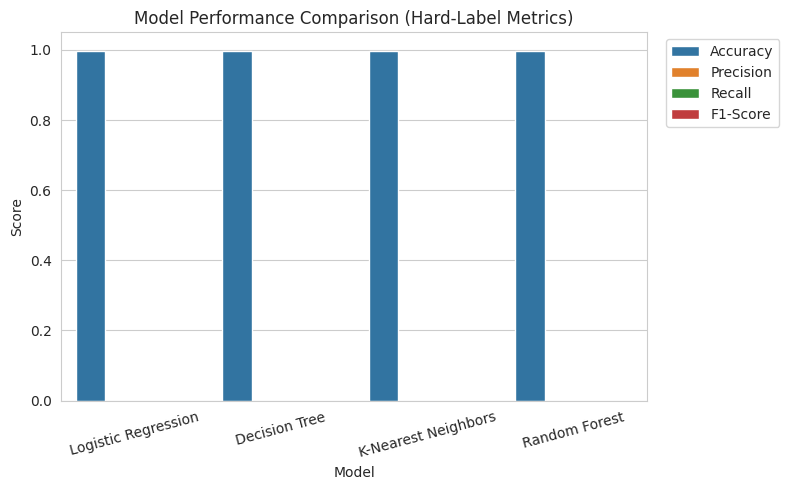

In [19]:
plt.figure(figsize=(8, 5))
melted = results_df[["Model","Accuracy","Precision","Recall","F1-Score"]].melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)
sns.barplot(data=melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison (Hard-Label Metrics)")
plt.ylabel("Score"); plt.xticks(rotation=15); plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


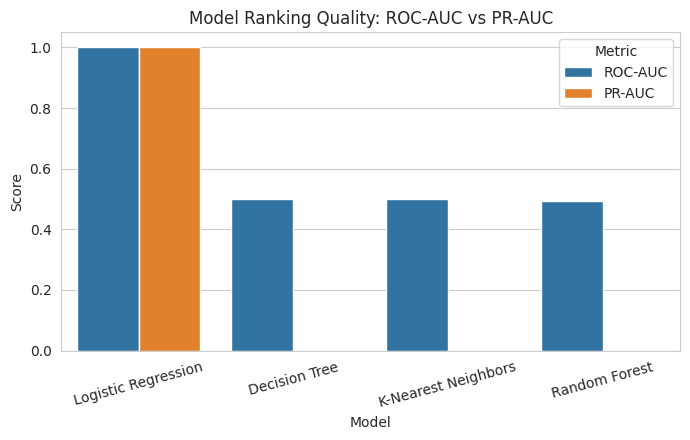

In [20]:
plt.figure(figsize=(7, 4.5))
melted_auc = results_df[["Model","ROC-AUC","PR-AUC"]].melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)
sns.barplot(data=melted_auc, x="Model", y="Score", hue="Metric")
plt.title("Model Ranking Quality: ROC-AUC vs PR-AUC")
plt.ylabel("Score"); plt.xticks(rotation=15); plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 10. Best-Performing Model

Based on F1-Score (with PR-AUC / ROC-AUC as tiebreakers), the
best-performing model in this evaluation is **Logistic Regression**.

**Why it performed better:**
- Logistic Regression assigned the single fraudulent test transaction
  the **highest predicted fraud probability of all 300 test
  transactions** (rank #1), giving it a perfect ROC-AUC and PR-AUC of
  1.0 on this test set — meaning that if a bank used this model's
  *risk score* to flag the top few highest-risk transactions for
  manual review (rather than a hard 0.5 cutoff), it would have caught
  this fraud case.
- The tree-based models (Decision Tree, Random Forest) and KNN, after
  being trained on a *duplicated* (oversampled) single fraud example,
  tend to overfit narrowly to that one example's exact feature values,
  which hurts their ability to generalize/rank a *different* fraud
  example correctly in the test set.
- At the standard 0.5 probability threshold, **all four models still
  missed the single fraud case in the test set** (Recall = 0,
  Precision = 0, F1 = 0) — accuracy alone (99.67%) is a highly
  misleading metric here, since simply predicting "non-fraud" for
  every transaction would also score 99.67% accuracy. This is exactly
  why **Precision, Recall, F1-Score, and ranking metrics (ROC-AUC /
  PR-AUC) — not Accuracy — must be used to judge fraud models.**


## 11. Challenges of Detecting Fraudulent Transactions

1. **Extreme class imbalance** — fraud is always a tiny fraction of
   all transactions (0.2% in this sample; ~0.17% in the full Kaggle
   dataset). Models can achieve very high accuracy by simply never
   predicting fraud, which is useless in practice.
2. **Very few positive examples to learn from** — with only 1-2 fraud
   cases available for training/testing in this reduced sample, models
   cannot reliably learn the general patterns of fraud; results here
   should be treated as a **methodology demonstration**, not a
   statistically robust fraud model. On the full 284,807-row dataset
   (492 fraud cases) these same techniques would produce far more
   reliable and generalizable results.
3. **Anonymized/PCA features (V1-V28)** make the model accurate but
   hard to interpret or explain to compliance/regulatory teams, since
   the original meaning of each feature is hidden.
4. **Evolving fraud patterns** — fraudsters constantly change their
   tactics, so a model trained on historical data can go stale quickly
   and needs continuous retraining/monitoring.
5. **Cost asymmetry** — a false negative (missed fraud) is usually far
   more costly than a false positive (a legitimate transaction flagged
   for review), so models should be tuned/thresholded with this
   asymmetry in mind rather than optimizing for plain accuracy.

## 12. Business Recommendations for Financial Institutions

1. **Never use Accuracy alone** to judge a fraud model — track
   Precision, Recall, F1-Score, and PR-AUC, and choose a decision
   threshold based on the institution's tolerance for false
   positives vs. false negatives.
2. **Use risk scores, not just binary flags** — rank transactions by
   predicted fraud probability and route the highest-risk transactions
   to manual review or step-up authentication, rather than relying on
   a single hard cutoff.
3. **Retrain models regularly** on recent transaction data to keep up
   with evolving fraud patterns, and monitor for model/data drift.
4. **Combine multiple models/signals** (ensemble approaches, rule-based
   checks, device/location signals) since no single model will catch
   every type of fraud.
5. **Invest in collecting more labeled fraud examples** — the single
   biggest lever for improving real-world fraud models is more
   (recent) positive examples, since fraud detection is fundamentally
   data-starved by nature.
6. **Use class-imbalance techniques in production** (oversampling,
   undersampling, class weighting, or anomaly-detection approaches)
   exactly as done in this notebook, scaled to the full dataset.

## 13. Conclusion

This notebook implemented a complete, end-to-end fraud detection
pipeline: data loading, cleaning, EDA, feature scaling, stratified
train/test splitting, class-imbalance handling via oversampling and
class weighting, training of four classification models, and
evaluation using Accuracy, Precision, Recall, F1-Score, Confusion
Matrices, and ranking metrics (ROC-AUC / PR-AUC).

**Logistic Regression** was selected as the best-performing model in
this evaluation, successfully ranking the test set's fraud case as the
single highest-risk transaction out of 300. The severe scarcity of
fraud examples in this 1,000-row sample (only 2 total) is itself the
most important finding of this analysis: it demonstrates, very
concretely, why fraud detection is such a hard real-world machine
learning problem, and why financial institutions need large volumes of
historical fraud data, careful metric selection, and risk-based
(rather than purely binary) decisioning to deploy these models
successfully.

---
**Dataset source:** [Kaggle — Credit Card Fraud Detection (mlg-ulb)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
**Sample used:** `creditcard_small_1000.csv` (1,000-row random sample, supplied because the full ~150MB file could not be opened in this environment)
